# Ejercicio 2 - Glucólisis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.integrate import solve_ivp

Encontramos un equilibrio en $(x = \frac{1}{2},~ y = \frac{2}{1+4a})$. Una forma de ver que el equilibrio es único es graficando las nulclinas y viendo que se cruzan en un solo punto.

En este caso, las nulclinas son:

$$f(x,y) = 0 \Rightarrow y = \frac{x}{x^2 + a}$$

$$g(x,y) = 0 \Rightarrow y = \frac{1}{2(x^2 + a)}$$

Vamos a graficarlas:

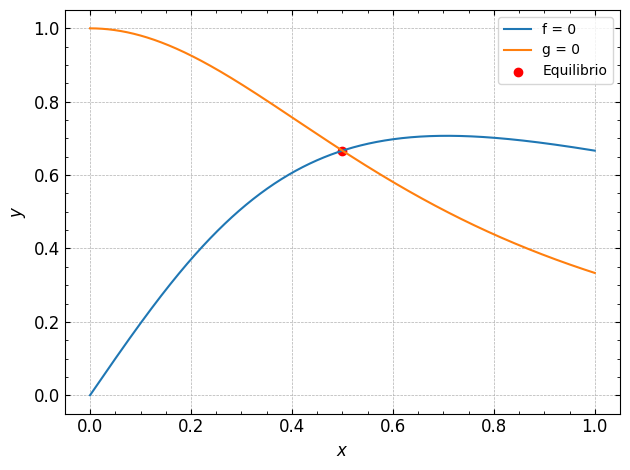

In [2]:
def nulclina_x(x, a):
    return x/(x*x + a)

def nullclina_y(x, a):
    return 1/(2*(x*x + a))

# Dado que son concentraciones, las tomamos entre 0 y 1
x = np.linspace(0, 1, 1000)
y = np.linspace(0, 1, 1000)

# Fijamos el parámetro a
a = 0.5

# Graficamos el punto de equilibrio
equilibrio = (0.5, 2/(1 + 4*a))

# Graficamos las nulclinas
plt.plot(x, nulclina_x(x, a), label='f = 0')
plt.plot(x, nullclina_y(x, a), label='g = 0')
plt.legend()
plt.xlabel('$x$', fontsize = 12)
plt.ylabel('$y$', fontsize = 12)
plt.scatter(equilibrio[0], equilibrio[1], color='red', label = "Equilibrio")
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc = 'best')
plt.tight_layout()
plt.savefig('IntersectNulclinas.pdf')
plt.show()

Dado que variar el parámetro $a$ cambia de la misma forma las dos nulclinas la intersección sigue siendo única.

Identifiquemos ahora donde $f > 0$ y $g > 0$, donde $f < 0$ y $g < 0$, donde $f > 0$ y $g < 0$ y donde $f < 0$ y $g > 0$.

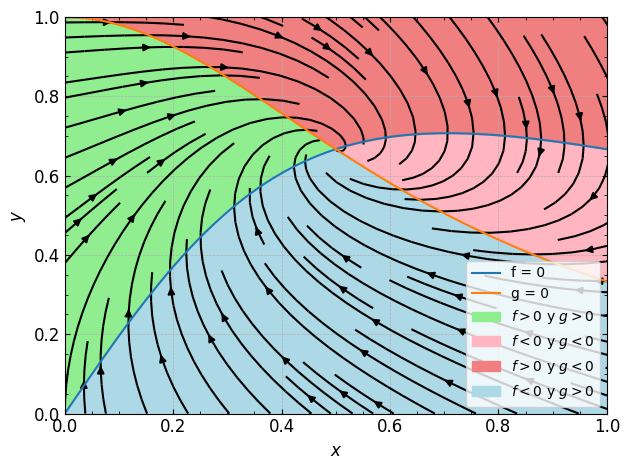

In [3]:
# Definimos las funciones f y g
fxy = lambda x,y,a : -x + a*y + x*x*y
gxy = lambda x,y,a : 0.5 - a*y - x*x*y
Y,X = np.mgrid[0:1.1:1000j, 0:1.1:1000j]
dxdt = fxy(X,Y,a)
dydt = gxy(X,Y,a)
fig, ax = plt.subplots()
ax.streamplot(X, Y, dxdt, dydt, color='black')
ax.plot(x, nulclina_x(x, a), label='f = 0')
ax.plot(x, nullclina_y(x, a), label='g = 0')
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_xlabel('$x$', fontsize = 12)
ax.set_ylabel('$y$', fontsize = 12)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)

f = nulclina_x(x, a)
g = nullclina_y(x, a)

ax.fill_between(x, np.where(f<g,f,g), y2=g,color='lightgreen',label=r"$f>0$ y $g>0$")
ax.fill_between(x, np.where(f<g,f,g), y2=f,color='lightpink',label=r"$f<0$ y $g<0$")
ax.fill_between(x, np.where(f>g,f,g), y2=1,color='lightcoral',label=r"$f>0$ y $g<0$")
ax.fill_between(x, np.where(f<g,f,g), y2=0,color='lightblue',label=r"$f<0$ y $g>0$")


plt.legend(loc = 'lower right')
plt.tight_layout()
plt.savefig('espaciodefases.pdf')
plt.show()

Viendo el gráfico podemos determinar las zonas donde se cumple cada una de las condiciones.

Al analizar la estabilidad lineal nos damos cuenta qué tenemos un espiral inestable para $a$ entre 0 y $\frac{-3+2\sqrt{3}}{4}$ y un espiral estable para $a$ entre $\frac{-3+2\sqrt{3}}{4}$ y $1.935$. Luego se tiene un nodo estable.

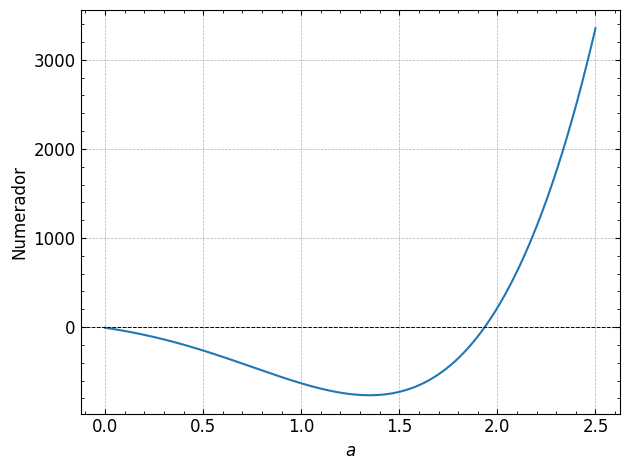

In [16]:
def numerador(a):
    num1 = (4 * a + 3 - 2*np.sqrt(3))**2
    num2 = (4 * a + 3 + 2*np.sqrt(3))**2
    return num1 * num2 - 16*(1 + 4*a)**3

a_s = np.linspace(0, 2.5, 1000)

plt.plot(a_s, numerador(a_s))
plt.xlabel('$a$', fontsize = 12)
plt.ylabel('Numerador', fontsize = 12)
plt.axhline(y=0, color='black', linestyle='--', lw = 0.7)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('numerador.pdf')

In [17]:
def glucolisis(t, u, a):
    x,y = u
    dxdt = -x + a*y + x*x*y
    dydt = 0.5 - a*y - x*x*y

    return [dxdt, dydt]

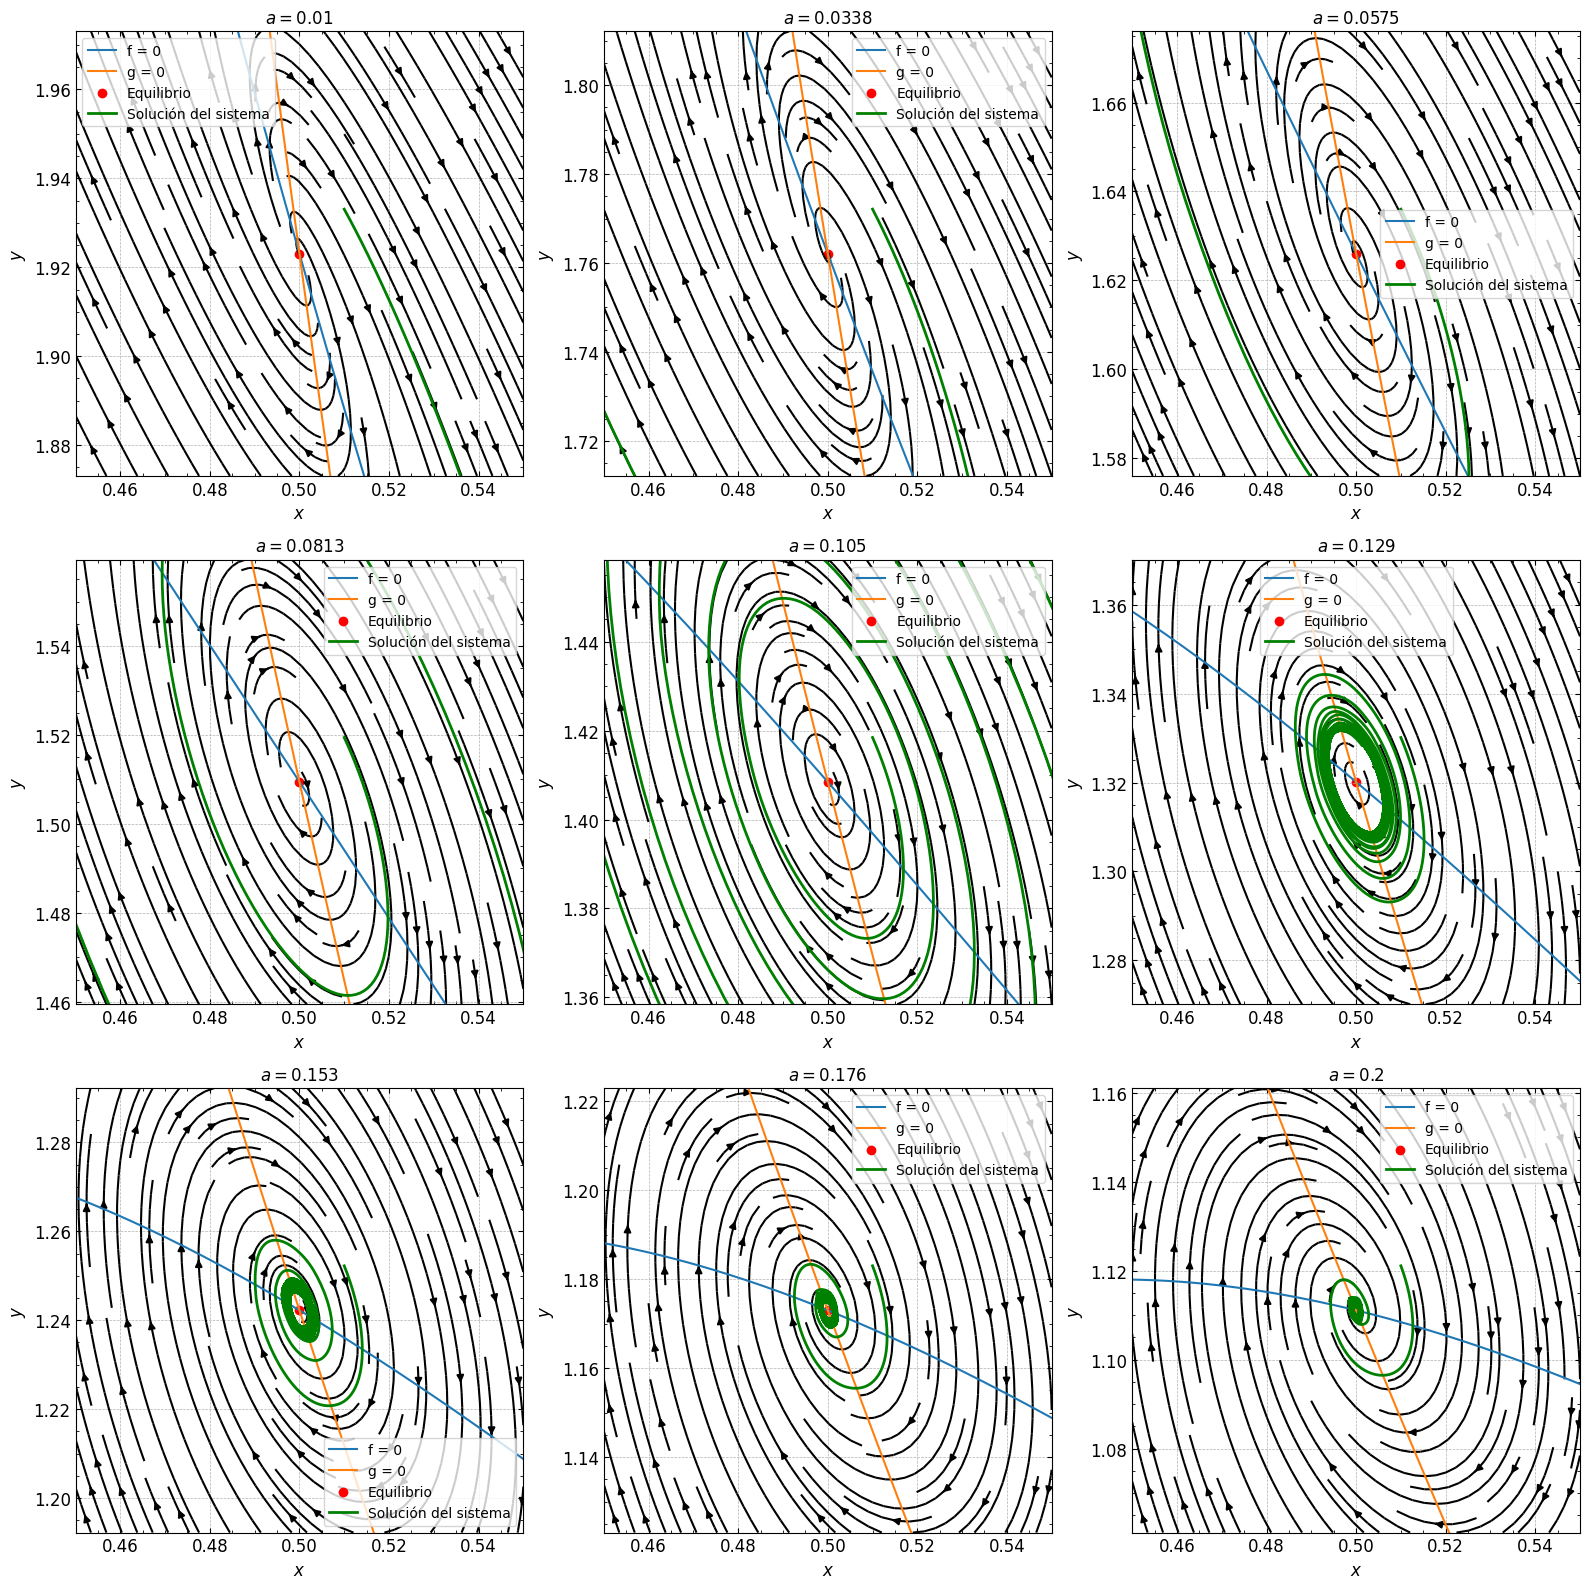

In [19]:
# Definimos los valores del parámetro de contról, vamos a hacer 4 gráficos con un a entre 0 y 0,13 con un paso de 0.0325
a = np.linspace(0.01, 0.2, 9)

fig, ax = plt.subplots(3, 3, figsize=(16, 16))
x_equilibrio = 0.5

# Para graficar la solución primero definimos el tiempo de integración
t_span = (0, 1000)

# Creamos los tiempos en los que queremos obtener la solución
t = np.linspace(t_span[0], t_span[1], 10000)


for i, a in enumerate(a):
    
    # Calculamos el nuevo y de equilibrio
    y_equilibrio = 2/(1 + 4*a)

    # Quiero ver todo cerca del punto de equilibrio
    x_lims = [x_equilibrio - 0.05, x_equilibrio + 0.05]
    y_lims = [y_equilibrio - 0.05, y_equilibrio + 0.05]
    
    # # Calculamos el streamplot y graficamos las nulclinas
    X,Y=np.meshgrid(np.linspace(x_lims[0], x_lims[1], 20),np.linspace(y_lims[0],y_lims[1],20))
    dxdt = fxy(X,Y,a)
    dydt = gxy(X,Y,a)
    ax[i//3,i%3].streamplot(X, Y, dxdt, dydt, color='black')
    ax[i//3,i%3].plot(x, nulclina_x(x, a), label='f = 0')
    ax[i//3,i%3].plot(x, nullclina_y(x, a), label='g = 0')
    
    # Graficamos el equilibrio
    ax[i//3,i%3].scatter(x_equilibrio, y_equilibrio, color='red', label = "Equilibrio")

    # Condiciones iniciales cerca del punto de equilibrio
    u0 = (x_equilibrio + 0.01, y_equilibrio + 0.01)

    # Resolvemos el sistema de ecuaciones diferenciales
    sol = solve_ivp(glucolisis, t_span, u0, args = (a,), t_eval = t)

    ax[i//3,i%3].plot(sol.y[0], sol.y[1], color='green', label = 'Solución del sistema', lw = 2)

    # Quiero ver cerca del punto de equilibrio
    ax[i//3,i%3].set_xlim(x_lims)
    ax[i//3,i%3].set_ylim(y_lims)
    

    ax[i//3,i%3].set_xlabel('$x$', fontsize = 12)
    ax[i//3,i%3].set_ylabel('$y$', fontsize = 12)
    ax[i//3,i%3].legend(loc = 'best')
    ax[i//3,i%3].set_title(f'$a = {a:.03}$')
    ax[i//3,i%3].xaxis.set_major_locator(plt.AutoLocator())
    ax[i//3,i%3].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i//3,i%3].yaxis.set_major_locator(plt.AutoLocator())
    ax[i//3,i%3].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i//3,i%3].yaxis.set_ticks_position('both')
    ax[i//3,i%3].xaxis.set_ticks_position('both')
    ax[i//3,i%3].tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
    ax[i//3,i%3].grid(linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('bifuracion.pdf')
plt.show()

Hagamos lo mismo para el caso en que $a$ es proximo a 1.935

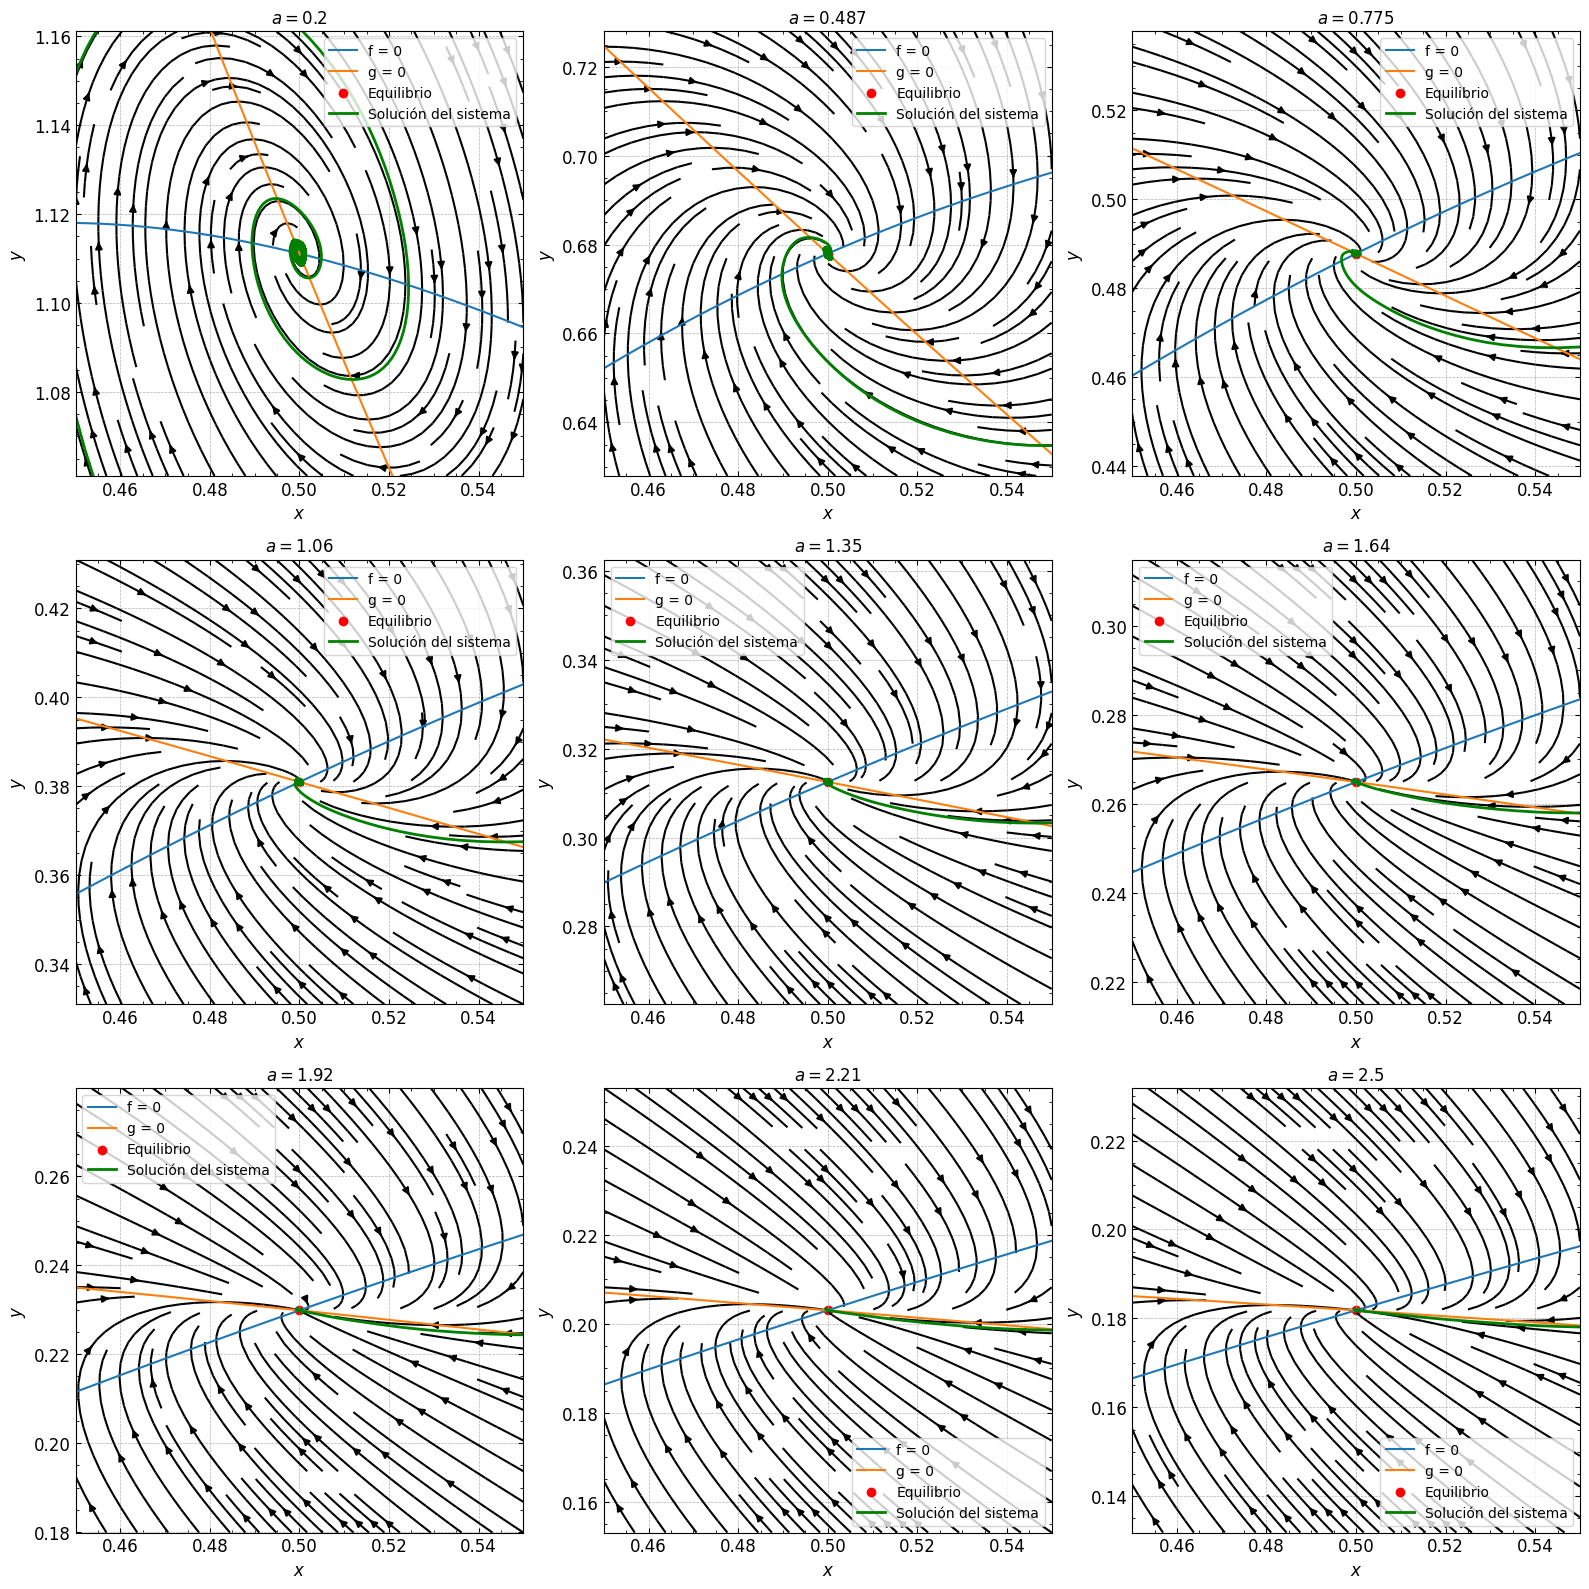

In [20]:
# Definimos los valores del parámetro de contról, vamos a hacer 4 gráficos con un a entre 0 y 0,13 con un paso de 0.0325
a = np.linspace(0.2, 2.5, 9)

fig, ax = plt.subplots(3, 3, figsize=(16, 16))
x_equilibrio = 0.5

for i, a in enumerate(a):
    
    # Calculamos el nuevo y de equilibrio
    y_equilibrio = 2/(1 + 4*a)

    # Quiero ver todo cerca del punto de equilibrio
    x_lims = [x_equilibrio - 0.05, x_equilibrio + 0.05]
    y_lims = [y_equilibrio - 0.05, y_equilibrio + 0.05]
    
    # # Calculamos el streamplot y graficamos las nulclinas
    X,Y=np.meshgrid(np.linspace(x_lims[0], x_lims[1], 20),np.linspace(y_lims[0],y_lims[1],20))
    dxdt = fxy(X,Y,a)
    dydt = gxy(X,Y,a)
    ax[i//3,i%3].streamplot(X, Y, dxdt, dydt, color='black')
    ax[i//3,i%3].plot(x, nulclina_x(x, a), label='f = 0')
    ax[i//3,i%3].plot(x, nullclina_y(x, a), label='g = 0')
    
    # Graficamos el equilibrio
    ax[i//3,i%3].scatter(x_equilibrio, y_equilibrio, color='red', label = "Equilibrio")

    # Condiciones iniciales cerca del punto de equilibrio
    u0 = (x_equilibrio + 0.1, y_equilibrio + 0.1)

    # Resolvemos el sistema de ecuaciones diferenciales
    sol = solve_ivp(glucolisis, t_span, u0, args = (a,), t_eval = t)

    ax[i//3,i%3].plot(sol.y[0], sol.y[1], color='green', label = 'Solución del sistema', lw = 2)

    # Quiero ver cerca del punto de equilibrio
    ax[i//3,i%3].set_xlim(x_lims)
    ax[i//3,i%3].set_ylim(y_lims)
    

    ax[i//3,i%3].set_xlabel('$x$', fontsize = 12)
    ax[i//3,i%3].set_ylabel('$y$', fontsize = 12)
    ax[i//3,i%3].legend(loc = 'best')
    ax[i//3,i%3].set_title(f'$a = {a:.03}$')
    ax[i//3,i%3].xaxis.set_major_locator(plt.AutoLocator())
    ax[i//3,i%3].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i//3,i%3].yaxis.set_major_locator(plt.AutoLocator())
    ax[i//3,i%3].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i//3,i%3].yaxis.set_ticks_position('both')
    ax[i//3,i%3].xaxis.set_ticks_position('both')
    ax[i//3,i%3].tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
    ax[i//3,i%3].grid(linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('bifuracion2.pdf')
plt.show()

# Cíclos de concentración

Veamos que pasa con las soluciones para distintos valores de $a$ cerca del punto crítico

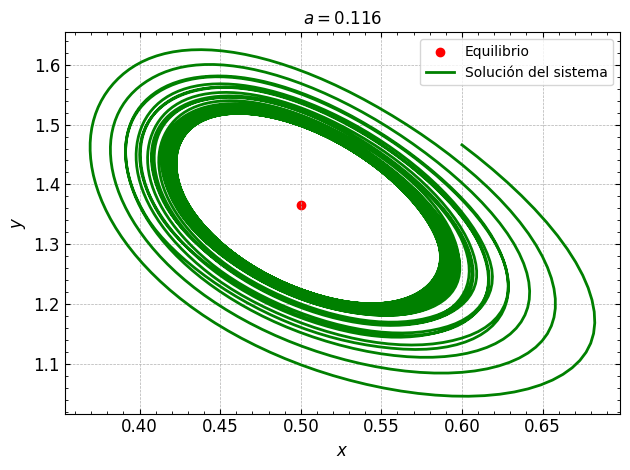

In [37]:
# Definimos los valores del parámetro de contról, vamos a hacer 4 gráficos con un a entre 0 y 0,13 con un paso de 0.0325
a = (-3 + 2 * np.sqrt(3)) / 4

fig, ax = plt.subplots()

# Buscamos los equilibrios
x_equilibrio = 0.5
y_equilibrio = 2/(1 + 4*a)

# Para graficar la solución primero definimos el tiempo de integración
t_span = (0, 1000)

# Creamos los tiempos en los que queremos obtener la solución
t = np.linspace(t_span[0], t_span[1], 10000)

ax.scatter(x_equilibrio, y_equilibrio, color='red', label = "Equilibrio")
u0 = (x_equilibrio + 0.1, y_equilibrio + 0.1)
sol = solve_ivp(glucolisis, t_span, u0, args = (a,), t_eval = t)
ax.plot(sol.y[0], sol.y[1], color='green', label = 'Solución del sistema', lw = 2)
ax.set_xlabel('$x$', fontsize = 12)
ax.set_ylabel('$y$', fontsize = 12)
ax.legend(loc = 'upper right')
ax.set_title(f'$a = {a:.04}$')
ax.xaxis.set_major_locator(plt.AutoLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_major_locator(plt.AutoLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
ax.grid(linestyle='--', linewidth=0.5)
# Quiero ver todo cerca del punto de equilibrio
x_lims = [x_equilibrio - 0.05, x_equilibrio + 0.05]
y_lims = [y_equilibrio - 0.05, y_equilibrio + 0.05]
# ax.set_xlim(x_lims)
# ax.set_ylim(y_lims)
plt.tight_layout()
plt.savefig('ciclosconcentracion.pdf')
plt.show()